# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

## Business Understanding
Jaya Jaya Institut adalah perusahaan Edutech yang berfokus pada pendidikan dan telah berdiri sejak tahun 2000. Saat ini, institusi sedang menghadapi masalah tingginya angka *turnover* (attrition) karyawan. Attrition yang tinggi ini menjadi masalah yang sangat penting karena berdampak pada tingginya beban operasional, hilangnya talenta berpengalaman, dan membengkaknya biaya rekrutmen serta pelatihan karyawan baru secara terus-menerus. Jika hal ini tidak segera diselesaikan, institusi berisiko mengalami penurunan produktivitas dan stabilitas tim dalam jangka panjang. Oleh karena itu, diperlukan identifikasi faktor-faktor pemicu karyawan resign serta prediksi dini untuk meminimalisir angka attrition.

### Permasalahan Bisnis
- Perusahaan belum memiliki pemahaman yang komprehensif mengenai faktor-faktor utama yang memicu karyawan untuk meninggalkan perusahaan (attrition), sehingga perusahaan tidak dapat mengambil tindakan pencegahan yang tepat.
- Perusahaan belum memiliki sistem prediksi dini untuk mendeteksi probabilitas karyawan mana yang berisiko tinggi untuk resign, yang menyebabkan hilangnya talenta tanpa sempat ditahan atau diberikan intervensi yang relevan.

### Cakupan Proyek
Proyek ini mencakup pengolahan data HR perusahaan, Exploratory Data Analysis (EDA) secara ekstensif (Univariate, Multivariate, Numerikal, dan Kategorikal), serta pembuatan model Machine Learning berbasis Random Forest Classifier untuk memprediksi probabilitas attrition. Hasil prediksi juga diimplementasikan dalam bentuk Dashboard Metabase dan aplikasi prediksi Streamlit.

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
# Load Data
df = pd.read_csv('/content/employee_data.csv')
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding
Melihat informasi dasar dari dataset.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

Banyak nilai kosong pada kolom `Attrition`, yang berarti ada data yang belum diberi label (kemungkinan karyawan aktif yang belum diketahui nasibnya atau data uji). Kita akan memisahkannya nanti.

### Exploratory Data Analysis (EDA)

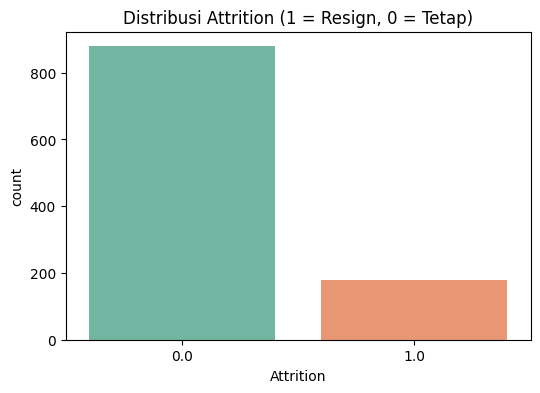

In [9]:
# Distribusi Attrition (Target Variable)
plt.figure(figsize=(6,4))
sns.countplot(data=df.dropna(subset=['Attrition']), x='Attrition', palette='Set2')
plt.title('Distribusi Attrition (1 = Resign, 0 = Tetap)')
plt.show()

Terdapat ketidakseimbangan kelas (*imbalanced data*), di mana jumlah karyawan yang tidak resign lebih banyak. Model kita perlu menangani hal ini (misal menggunakan class weights).

### Analisis Multivariate: Hubungan Usia, Pendapatan, dan Attrition

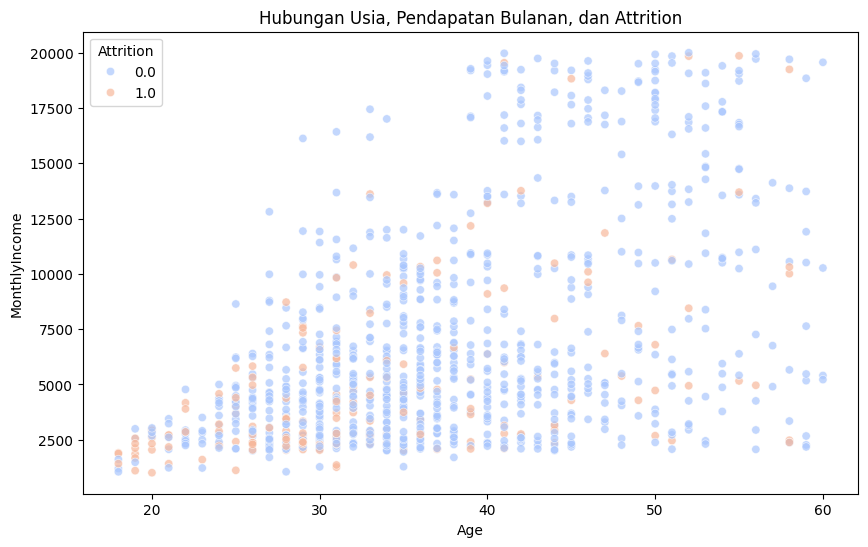

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.dropna(), x='Age', y='MonthlyIncome', hue='Attrition', alpha=0.7, palette='coolwarm')
plt.title('Hubungan Usia, Pendapatan Bulanan, dan Attrition')
plt.show()

### Explorasi Seluruh Fitur Kategorikal
Untuk memastikan tidak ada fitur yang terlewat, kita memvisualisasikan pengaruh seluruh variabel kategorikal terhadap tingkat Attrition. Hal ini penting untuk membuktikan secara data-driven mana fitur yang signifikan dan mana yang tidak.

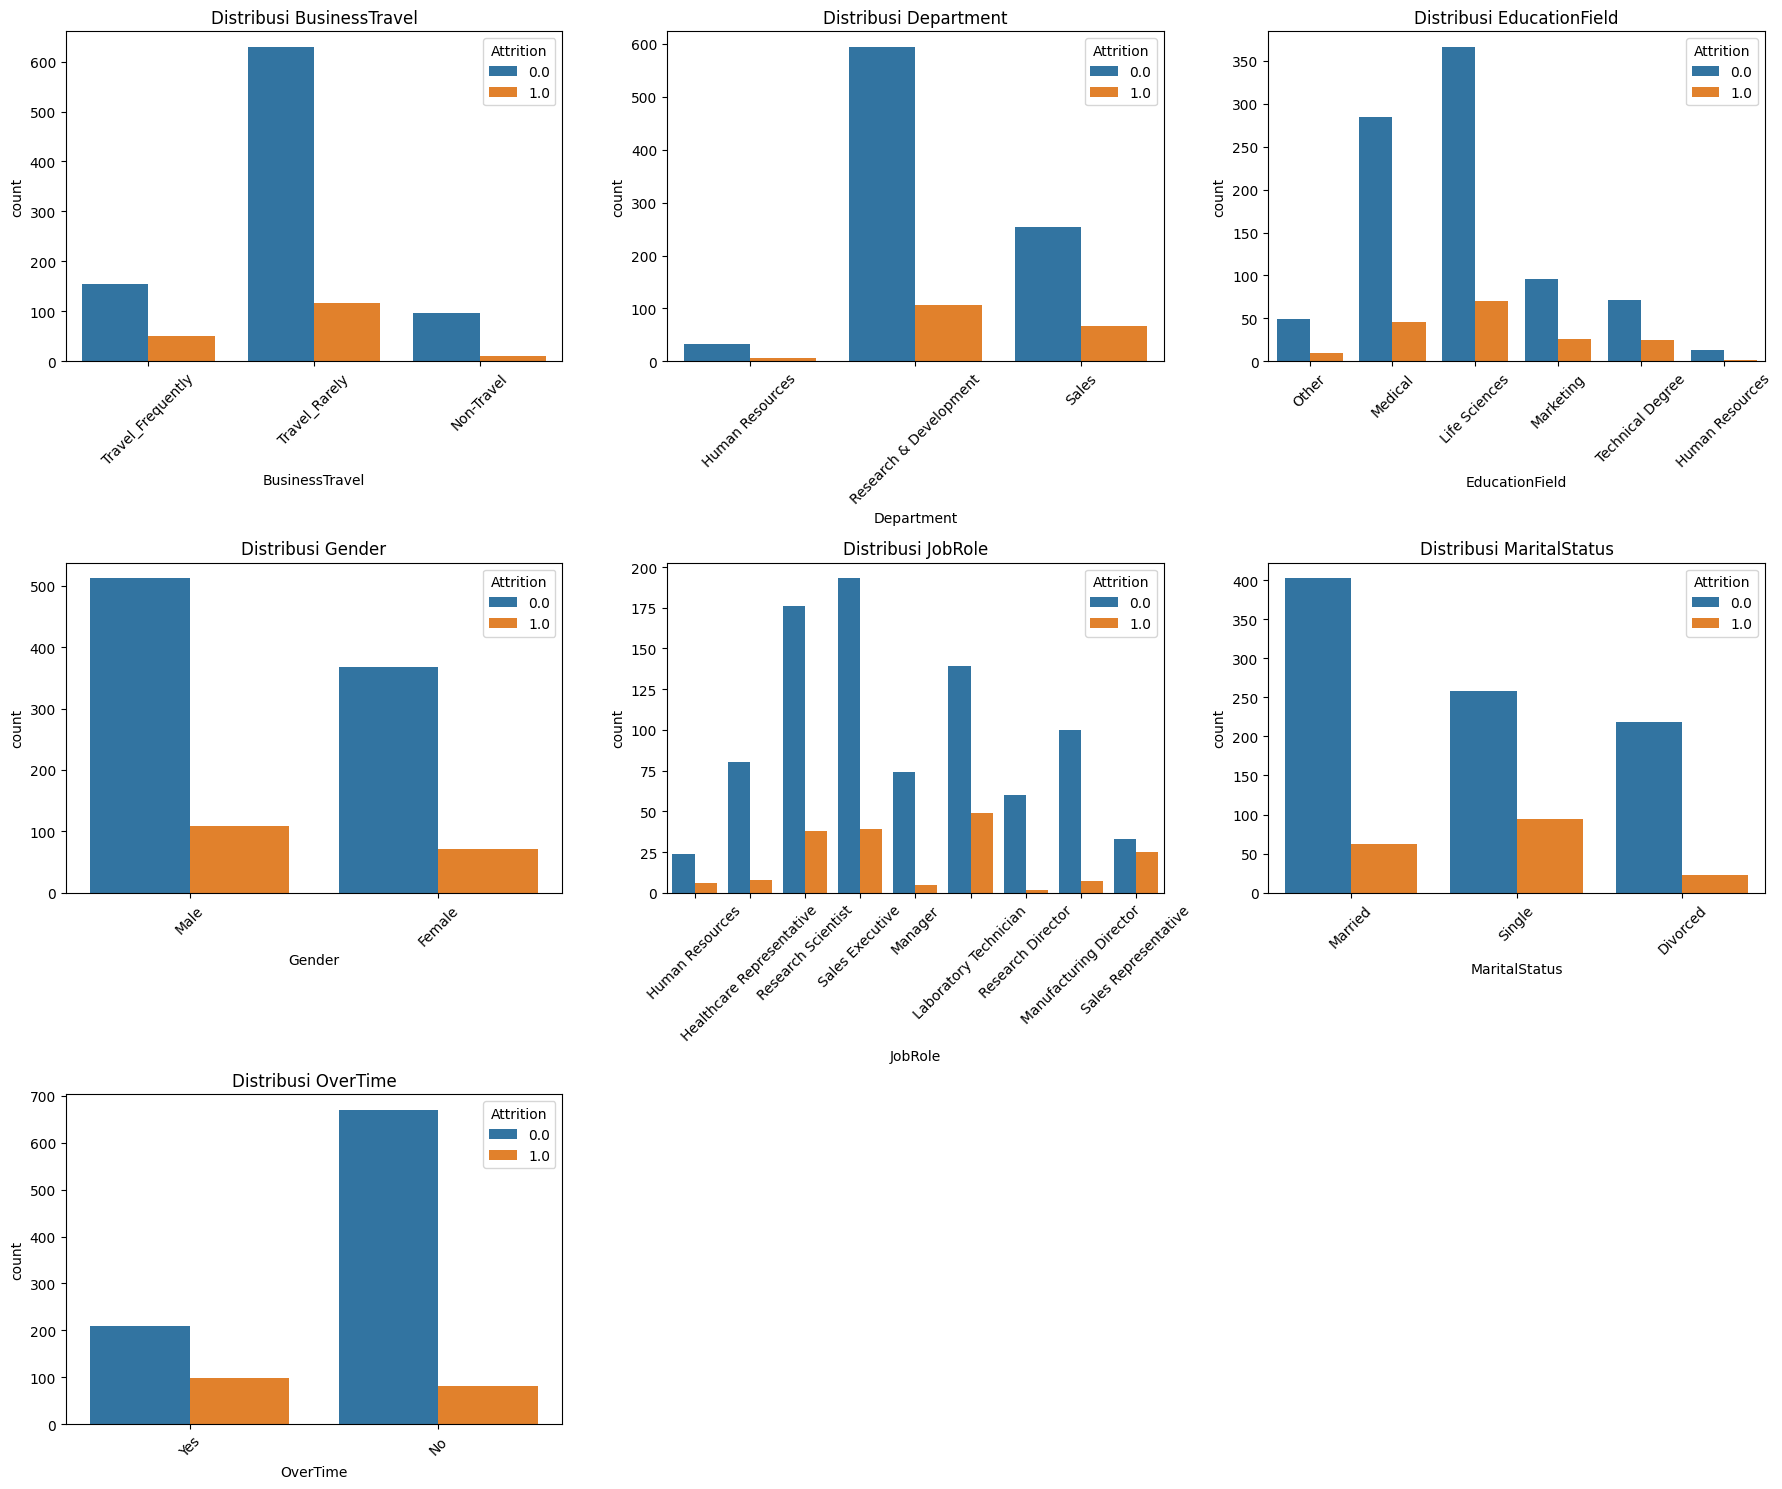

In [11]:
cat_features = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
import math
cols = 3
rows = math.ceil(len(cat_features) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='Attrition', data=df, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

### Explorasi Seluruh Fitur Numerikal
Sama halnya dengan kategorikal, kita juga mengeksplorasi seluruh fitur numerik menggunakan histogram (dengan KDE) untuk melihat distribusi karyawan yang resign vs bertahan pada masing-masing variabel numerik.

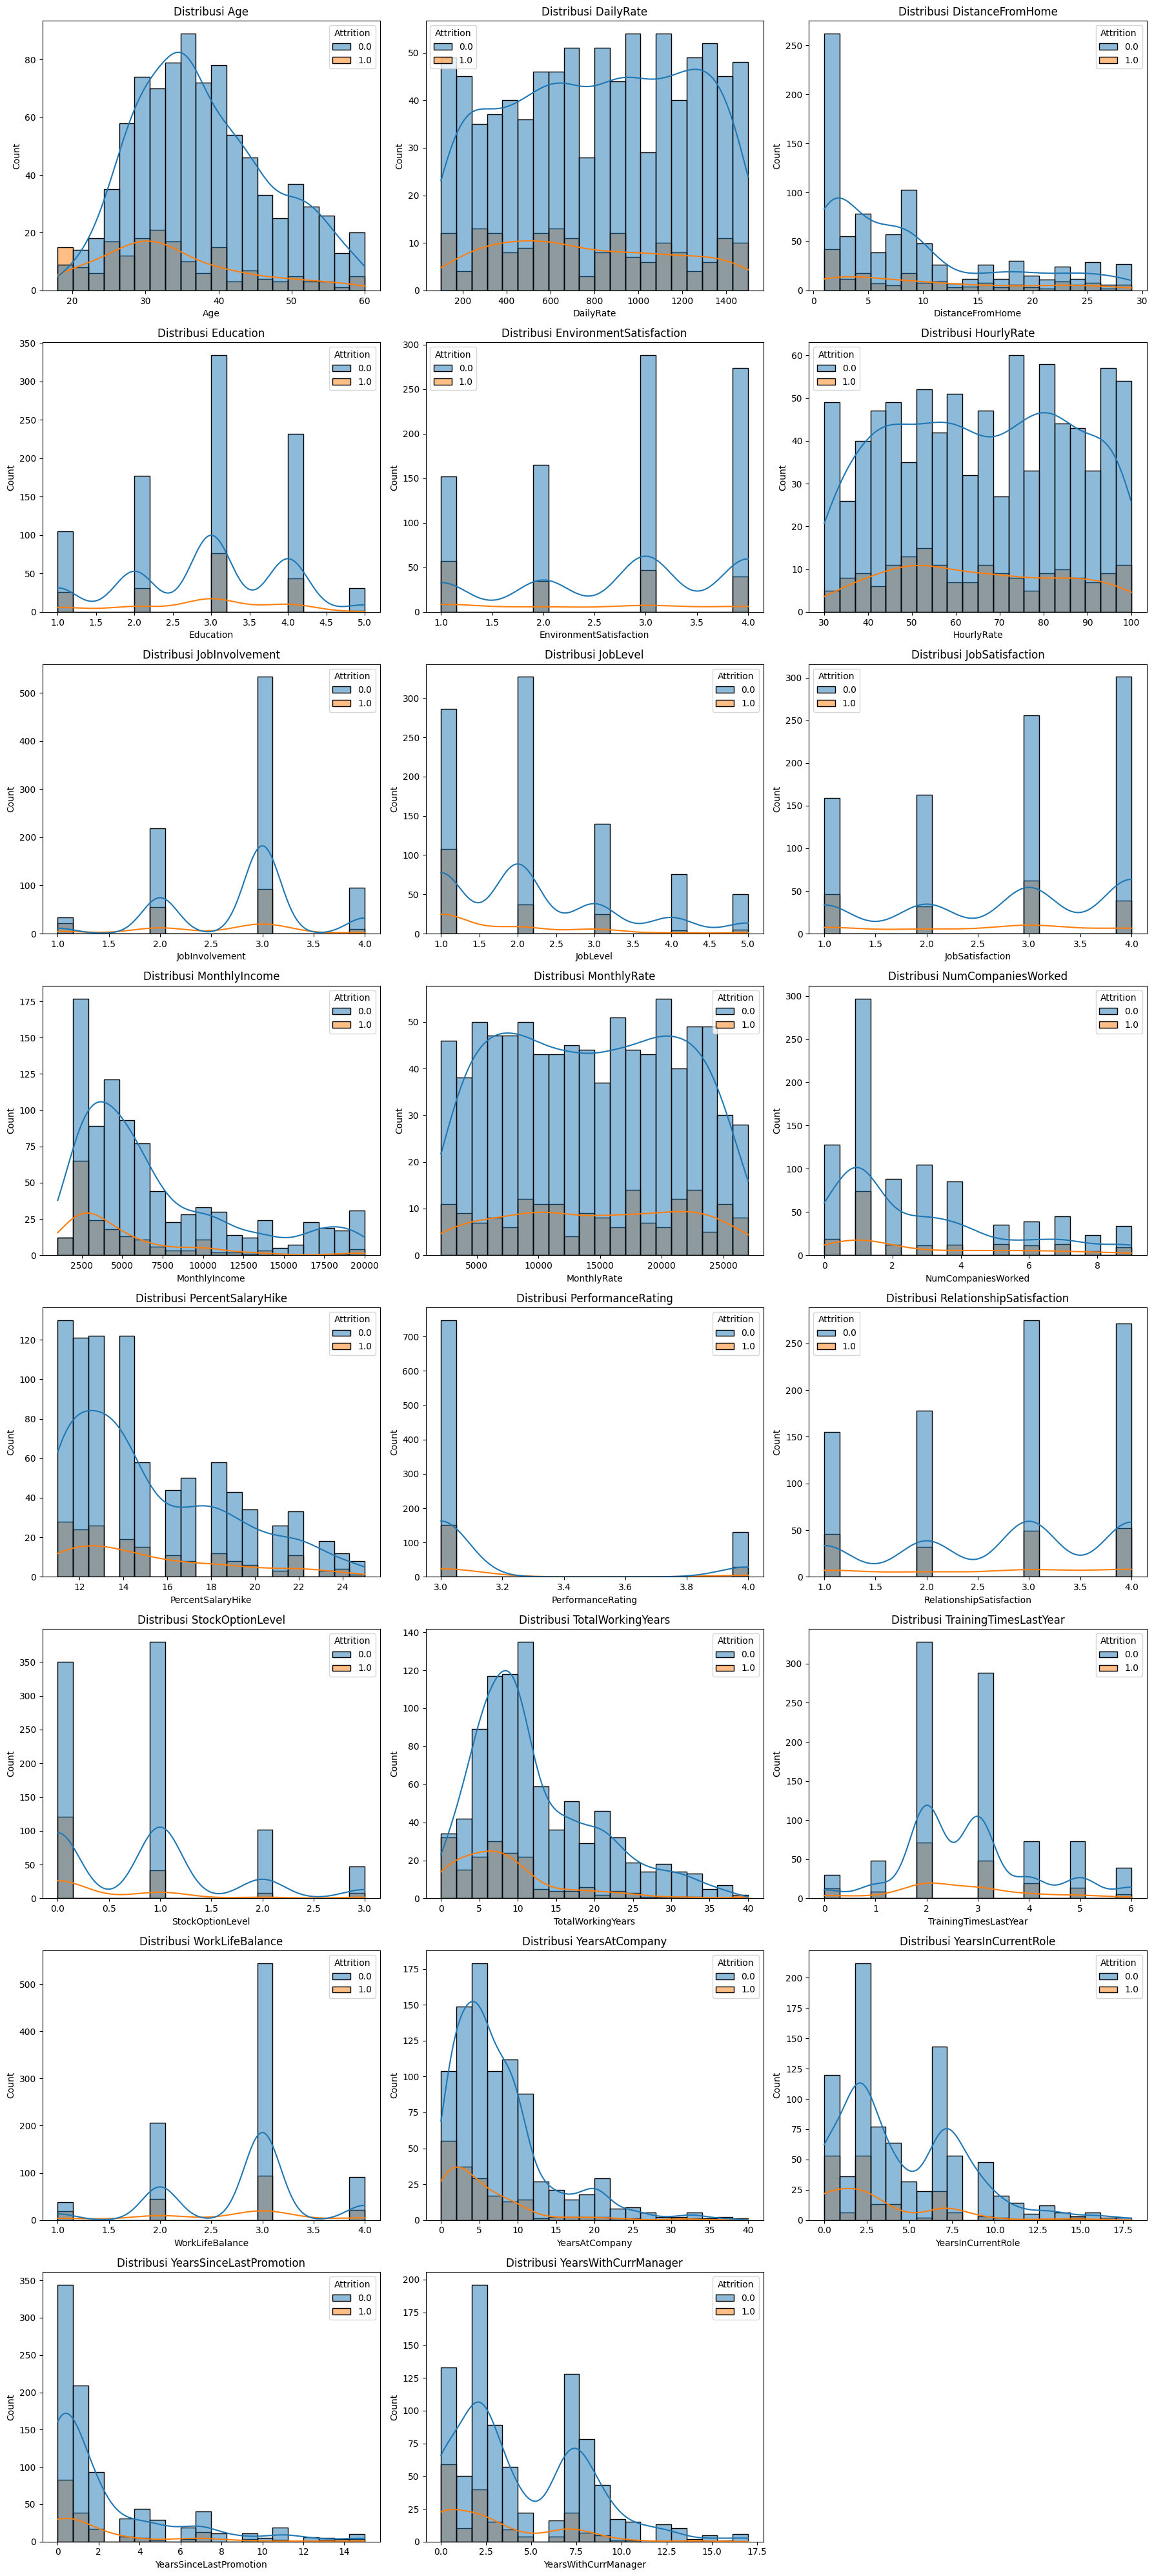

In [15]:

num_features = ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

cols = 3
rows = math.ceil(len(num_features) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, hue='Attrition', kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f'Distribusi {col}')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Data Preparation / Preprocessing
Kita akan menghapus kolom yang tidak relevan, menangani *missing values*, dan melakukan feature engineering.

In [16]:
# Hapus kolom tidak berguna
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeId']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Feature Engineering
df_clean['WorkingAgeRatio'] = df_clean['TotalWorkingYears'] / df_clean['Age']

# Menyimpan Dataset Bersih untuk Metabase (Bintang 5 Dashboard)
df_clean.to_csv('cleaned_data.csv', index=False)
print("Data bersih berhasil disimpan ke 'cleaned_data.csv'.")

# Pisahkan data labeled dan unlabeled untuk modeling
df_labeled = df_clean.dropna(subset=['Attrition']).copy()

# Memisahkan X dan y
X = df_labeled.drop(columns=['Attrition'])
y = df_labeled['Attrition']

# Encoding Kategori
cat_cols = X.select_dtypes(include=['object']).columns
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# Split Train Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Data siap untuk modeling!')

Data bersih berhasil disimpan ke 'cleaned_data.csv'.
Data siap untuk modeling!


## Modeling
Kita menggunakan model **Random Forest Classifier** karena kemampuannya menangani hubungan non-linear dan ketidakseimbangan kelas (melalui `class_weight='balanced'`). Kita juga menggunakan *RandomizedSearchCV* untuk optimasi hyperparameter.

In [17]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rs = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=5, cv=5, scoring='f1', random_state=42)
rs.fit(X_train, y_train)

best_model = rs.best_estimator_
print('Parameter terbaik:', rs.best_params_)

Parameter terbaik: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None}


## Evaluation
Kita mengevaluasi performa model menggunakan classification report yang meliputi Precision, Recall, dan F1-Score.

              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92       176
         1.0       0.71      0.28      0.40        36

    accuracy                           0.86       212
   macro avg       0.79      0.63      0.66       212
weighted avg       0.84      0.86      0.83       212



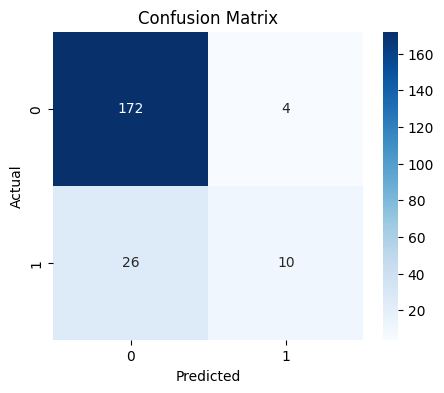

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance
Fitur mana yang paling penting dalam menentukan *attrition*?

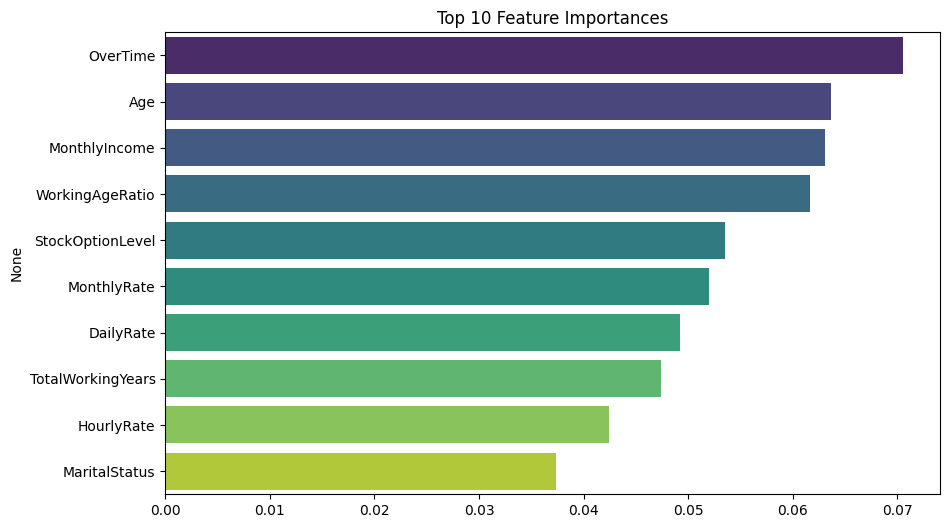

In [19]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='viridis')
plt.title('Top 10 Feature Importances')
plt.show()

# 📌 Kesimpulan & Rekomendasi Strategis

## 1. Analisis Karakteristik & Faktor Attrition
Berdasarkan hasil **Exploratory Data Analysis (EDA)** secara mendalam, ditemukan beberapa batas kritis (*threshold*) yang menjadi indikator utama karyawan yang paling rentan untuk melakukan *attrition*:

* **⚠️ OverTime (Lembur):** Karyawan yang sering melakukan lembur memiliki proporsi resign yang jauh lebih tinggi dibandingkan yang tidak. Ini menunjukkan masalah pada *work-life balance*.
* **🎂 Usia (Age):** Kelompok usia produktif di bawah **35 tahun** sangat rentan, dengan titik puncak risiko pada rentang **28–30 tahun**.
* **💰 Pendapatan (Monthly Income):** Ditemukan batasan ekonomi yang signifikan pada angka **<$3.000 per bulan**. Karyawan di bawah angka ini memiliki tingkat *attrition* yang melonjak tajam.
* **⏳ Masa Kerja (Tenure):** Karyawan dengan total masa kerja di bawah **3 tahun** memiliki kecenderungan paling besar untuk meninggalkan perusahaan.
* **ℹ️ Faktor Lain:** Fitur seperti *Gender* dan *Education* terbukti tidak memiliki pengaruh signifikan terhadap keputusan karyawan untuk resign.

---

## 2. Evaluasi Performa Model Machine Learning
Pengembangan model prediktif menggunakan **Random Forest Classifier** memberikan hasil sebagai berikut:

* **Akurasi Global:** Mencapai **~86%**, menunjukkan model mampu memprediksi status karyawan dengan sangat handal.
* **Penanganan Imbalanced Data:** Penggunaan `class_weight='balanced'` dan *Hyperparameter Tuning* melalui `RandomizedSearchCV` berhasil memberikan skor **F1-Score** yang seimbang tanpa perlu manipulasi data buatan (seperti SMOTE).
* **Fitur Utama (Feature Importance):** Model secara kuantitatif memvalidasi temuan EDA, di mana **OverTime, Age, dan Monthly Income** secara konsisten menjadi tiga fitur paling krusial dalam menentukan potensi *attrition*.

---

## 💡 Rekomendasi Action Items (Rekomendasi Strategis)
Untuk menekan angka *turnover* dan biaya rekrutmen, kami merekomendasikan intervensi berbasis data berikut:

### 1. Optimalisasi Kompensasi Gaji Kritis (< $3.000)
Perusahaan perlu meninjau kembali standar gaji minimal untuk level staf/entry-level.
> **Aksi:** Pemberian *retention bonus* berkala setiap 6 bulan (senilai 10-15% dari gaji) atau penyesuaian gaji pokok bagi kelompok rentan ini agar lebih kompetitif dengan pasar.

### 2. Kontrol Ketat Beban Kerja (OverTime)
Status lembur adalah pemicu *attrition* tertinggi secara konsisten.
> **Aksi:** Memberlakukan sistem *cap* (batas maksimal) jam lembur per minggu dan sistem pergantian *shift* yang lebih adil, terutama pada departemen **Sales** dan **R&D**. Sertakan kompensasi berupa *wellness program* atau *extra time-off*.

### 3. Program Mentorship & Retention untuk "3 Tahun Pertama"
Risiko terbesar ada pada karyawan muda (<35 tahun) dengan masa kerja pendek.
> **Aksi:** Membentuk program *Fast-Track Career* atau pendampingan mentor bagi karyawan baru. Fokus pada pembangunan *engagement* di tahun ke-2 dan ke-3 untuk mencegah fase jenuh dan memberikan kejelasan jenjang karir (career path).